# Multi Qubit Systems and Entanglement

This notebook continues directly from the previous one. There we built single qubit states, placed them on the Bloch sphere, and met the single qubit gates. Now we move to systems of two and three qubits.

We cover two topics, numbered as a continuation of the previous notebook.

8. Two qubit and three qubit gates, CNOT, SWAP, and Toffoli
9. Entanglement and the Bell state

Every code cell is kept as short as possible. Each one does a single small thing, and the markdown text right above it tells you, line by line, what it is about to do. Read the text first, then run the cell, then compare what you see with what the text said would happen.

## Setup

We only need to do this once. Run the cell below before anything else in this notebook.

- `%pip install ...` makes sure the needed packages are present.
- `import numpy as np` gives us NumPy, which we already used in the first notebook.
- `from qiskit import QuantumCircuit` gives us the tool for building a circuit.
- `from qiskit.quantum_info import Statevector, Operator` gives us four tools we will use throughout this notebook: `Statevector` for a fully known state, `Operator` for a gate's matrix.
- `from qiskit.visualization import plot_bloch_multivector, plot_state_city, plot_histogram` gives us three ways to draw a state as a picture. `plot_histogram` is new here, it draws a set of probabilities as bars, one bar per possible outcome.

We will not need a simulator or shots in this notebook. `Statevector` already tells us the exact outcome and the exact probabilities directly, with no need to run a circuit many times and count results. The simulator becomes useful later in the course, once we reach algorithms where we genuinely want to watch randomness play out over many runs.

In [1]:
%pip install qiskit matplotlib numpy
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, Operator
from qiskit.visualization import plot_bloch_multivector, plot_histogram

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 79.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.5 MB/s eta 0:00:00


## 8. Two Qubit and Three Qubit Gates

A single qubit gate is a two by two matrix. When we have more qubits, the gates get bigger. A gate on two qubits is a four by four matrix, and a gate on three qubits is an eight by eight matrix.

The most useful multi qubit gates are controlled gates. A controlled gate looks at one qubit, called the control, and acts on another qubit, called the target, only when the control is $|1\rangle$. This is how one qubit gets to affect another.

One thing to know up front. Qiskit writes qubit 0 on the right of a result. So in a printout like `11`, the right character is qubit 0 and the left character is qubit 1. When we write `cx(0, 1)`, qubit 0 is the control and sits on the right.

### The CNOT gate

CNOT flips the target when the control is $|1\rangle$.

- `cnot = QuantumCircuit(2)` starts a blank circuit with two qubits, no gates yet.
- `cnot.cx(0, 1)` adds a CNOT gate, with qubit 0 as the control and qubit 1 as the target.
- `print(np.real(Operator(cnot).data))` prints the matrix for this gate, as real numbers, so we can see its shape.

In [2]:
cnot = QuantumCircuit(2)
cnot.cx(0, 1)
print(np.real(Operator(cnot).data))

[[1. 0. 0. 0.]
 [0. 0. 0. 1.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]]


Look at the shape of this matrix closely. The top left quarter is the identity matrix, and the bottom right quarter is the X gate's matrix. That is not an accident, and it is the pattern every controlled gate follows. When the control is $|0\rangle$, the identity quarter is used and nothing happens. When the control is $|1\rangle$, the other quarter is used, and whatever gate sits there is applied to the target. CNOT is a controlled X.

### A family of controlled gates

Once you see CNOT as a controlled X, a natural question follows. What if we control a different gate instead? Qiskit has these built in directly. We build four of them here, CX, CY, CZ, and a controlled Hadamard, and print each matrix so we can compare.

Three of these four gates only ever produce real numbers, so we print just the real part to keep things readable, the same way we did for CNOT above. The Y gate is the one exception in this entire course, it genuinely needs imaginary numbers to be written down correctly, so for CY alone we print the full matrix, imaginary parts included, rather than hide them.

- `cx = QuantumCircuit(2)` and `cx.cx(0, 1)` build a controlled X, the same CNOT from above.
- `cy = QuantumCircuit(2)` and `cy.cy(0, 1)` build a controlled Y.
- `cz = QuantumCircuit(2)` and `cz.cz(0, 1)` build a controlled Z.
- `ch = QuantumCircuit(2)` and `ch.ch(0, 1)` build a controlled Hadamard.
- The first, third, and fourth `print` lines show only the real part of each matrix. The second `print` line, for CY, shows the full matrix with its imaginary part intact.

In [3]:
cx = QuantumCircuit(2)
cx.cx(1, 0)
print("CNOT")
print(np.round(Operator(cx).data, 3))

cy = QuantumCircuit(2)
cy.cy(1, 0)
print("CY")
print(np.round(Operator(cy).data, 3))

cz = QuantumCircuit(2)
cz.cz(1, 0)
print("CZ")
print(np.round(Operator(cz).data, 3))

ch = QuantumCircuit(2)
ch.ch(1, 0)
print("CH")
print(np.round(Operator(ch).data, 3))

CNOT
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j]]
CY
[[1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.-1.j]
 [0.+0.j 0.+0.j 0.+1.j 0.+0.j]]
CZ
[[ 1.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  1.+0.j  0.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  1.+0.j  0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -1.+0.j]]
CH
[[ 1.   +0.j  0.   +0.j  0.   +0.j  0.   +0.j]
 [ 0.   +0.j  1.   +0.j  0.   +0.j  0.   +0.j]
 [ 0.   +0.j  0.   +0.j  0.707+0.j  0.707+0.j]
 [ 0.   +0.j  0.   +0.j  0.707+0.j -0.707+0.j]]


All four matrices have the exact same shape. The top left quarter is always the identity matrix. The bottom right quarter is different each time, X for CX, Y for CY, Z for CZ, and H for CH. Look at the CY matrix specifically, its bottom right quarter has `1j` and `-1j` in it rather than plain numbers, that is the Y gate's imaginary part showing through, exactly where the pattern says it should sit.

This is the general rule behind every controlled gate you will ever meet in this course. Take any single qubit gate, and you can turn it into a two qubit controlled gate the same way.

### The SWAP gate

SWAP exchanges the states of two qubits. It does not follow the controlled gate pattern above, since it has no control qubit at all, both qubits act on each other equally.

- `swap = QuantumCircuit(2)` starts a blank two qubit circuit.
- `swap.swap(0, 1)` adds a SWAP gate between qubit 0 and qubit 1.
- `print(np.real(Operator(swap).data))` prints its matrix.

In [4]:
swap = QuantumCircuit(2)
swap.swap(0, 1)
print(np.real(Operator(swap).data))

[[1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [0. 0. 0. 1.]]


To see it work, we put a $1$ on qubit 0, then swap. If SWAP does its job, the $1$ should move over to qubit 1.

- `qc.x(0)` sets qubit 0 to $1$.
- `qc.swap(0, 1)` swaps the two qubits.
- `state = Statevector(qc)` reads off the result.
- `plot_histogram(state.probabilities_dict())` draws the probability of each outcome as a bar chart.

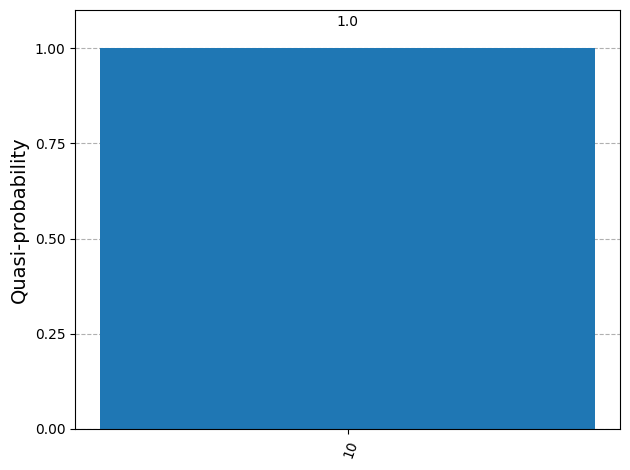

In [5]:
qc = QuantumCircuit(2)
qc.x(0)
qc.swap(0, 1)
state = Statevector(qc)
plot_histogram(state.probabilities_dict())

One bar stands at probability 1, at `10`, meaning qubit 1 now holds the $1$ and qubit 0 holds the $0$. The other three outcomes have no bar at all, since their probability is exactly 0. The two qubits traded values, which is exactly what SWAP does.

### The Toffoli gate

The Toffoli gate has two controls and one target. It flips the target only when both controls are $|1\rangle$. It is an eight by eight matrix, since it acts on three qubits.

- `toffoli = QuantumCircuit(3)` starts a blank three qubit circuit.
- `toffoli.ccx(0, 1, 2)` adds a Toffoli gate. Qubits 0 and 1 are the two controls, qubit 2 is the target.
- `print(np.real(Operator(toffoli).data))` prints its matrix.

In [6]:
toffoli = QuantumCircuit(3)
toffoli.ccx(0, 1, 2)
print(np.real(Operator(toffoli).data))

[[1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]]


First we set only one control to $1$, qubit 0, and leave qubit 1 at $0$. Since both controls are not $1$, the target should stay put.

- `qc.x(0)` sets qubit 0 to $1$. Qubit 1 stays at $0$, since we do not touch it.
- `qc.ccx(0, 1, 2)` adds the Toffoli gate.

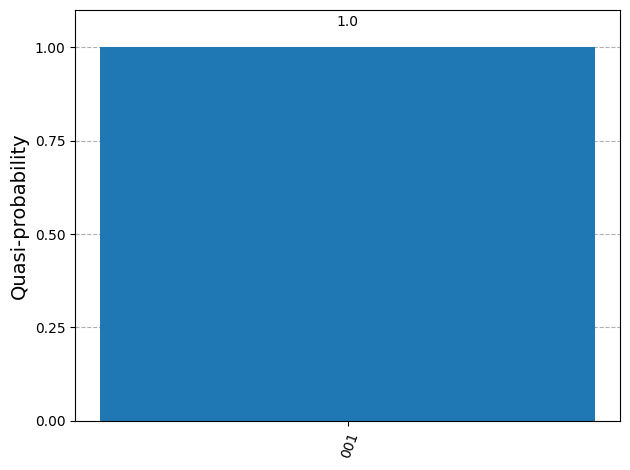

In [7]:
qc = QuantumCircuit(3)
qc.x(0)
qc.ccx(0, 1, 2)
state = Statevector(qc)
plot_histogram(state.probabilities_dict())

One bar stands at `001`, the target qubit 2 is still $0$.

Now we set both controls to $1$ and check again.

- `qc.x(0)` sets qubit 0 to $1$.
- `qc.x(1)` sets qubit 1 to $1$ as well.
- `qc.ccx(0, 1, 2)` adds the Toffoli gate, now with both controls at $1$.

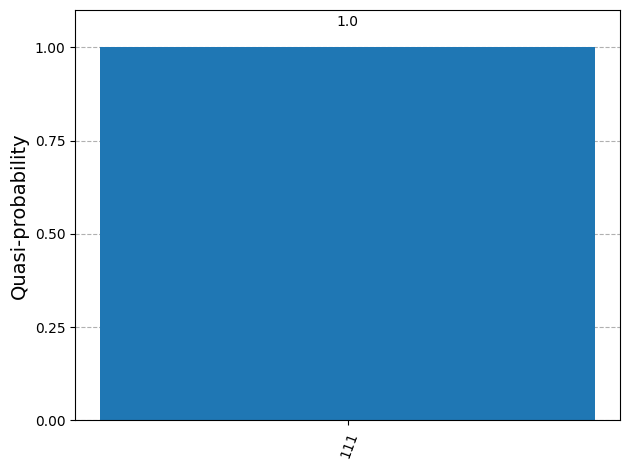

In [8]:
qc = QuantumCircuit(3)
qc.x(0)
qc.x(1)
qc.ccx(0, 1, 2)
state = Statevector(qc)
plot_histogram(state.probabilities_dict())

Now the bar stands at `111`, the target flipped to $1$ because both controls were $1$. Notice that the target started at $0$ and ended as the AND of the two controls. Toffoli computes a classical AND, and we will see later in this notebook that it does so in a way that can be undone.

## 9. Entanglement and the Bell State

The Bell state is the single most important two qubit state in this subject. We are going to build it, check it carefully, measure it, look at it on the Bloch sphere, and compare it to a state that looks similar but is not entangled.

Along the way we will quietly touch three ideas that you have actually already been using without a name attached: every valid state has length one, every gate that changes a state is reversible, and every probability we compute is the amplitude size squared. You do not need to memorise these as separate rules, you have already been checking them by hand in the section above.

### Building the Bell state

The Bell state is built with exactly two gates: a Hadamard, followed by a CNOT.

- `qc = QuantumCircuit(2)` starts a two qubit circuit.
- `qc.h(0)` puts qubit 0 into superposition.
- `qc.cx(0, 1)` links qubit 1 to qubit 0. This second step is what actually creates the entanglement, the CNOT makes qubit 1's value depend entirely on qubit 0.
- `bell = Statevector(qc)` reads off the resulting state.
- `print(bell.data)` prints the state vector.

In [ ]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
bell = Statevector(qc)
#bell.draw('latex')
print(bell.data)

[0.70710678+0.j 0.        +0.j 0.        +0.j 0.70710678+0.j]


### Measuring the Bell state

Now we ask what happens when we measure both qubits. `probabilities_dict` gives us the probability of each outcome directly, and this probability is always the size of the amplitude, squared. We draw it with `plot_histogram`, one bar per possible outcome.

- `plot_histogram(bell.probabilities_dict())` draws the probability of each of the four possible outcomes as a bar chart.

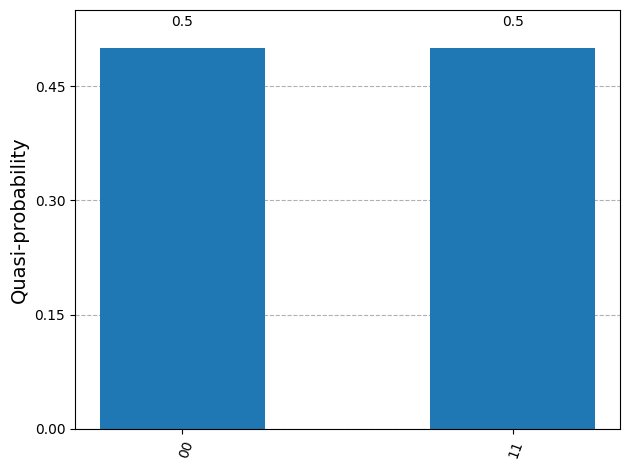

In [ ]:
plot_histogram(bell.probabilities_dict())

Only two bars appear, `00` and `11`, each at one half. The outcomes `01` and `10` have no bar at all, their probability is exactly 0. This is the fingerprint of entanglement. Because the answer is only ever `00` or `11`, the moment you learn one qubit you instantly know the other.

Now compare a state that is not entangled. We put both qubits into superposition separately, with no link between them.

- `qc.h(0)` puts qubit 0 into superposition, on its own.
- `qc.h(1)` puts qubit 1 into superposition, on its own, with no gate connecting the two qubits.

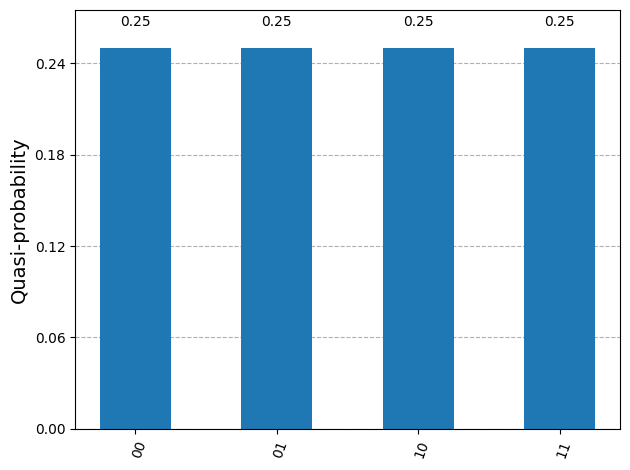

In [ ]:
qc = QuantumCircuit(2)
qc.h(0)
qc.h(1)
independent = Statevector(qc)
plot_histogram(independent.probabilities_dict())

This time all four bars appear, each at one quarter. Here is the plain reason why.

Think of each qubit as its own separate coin flip. `qc.h(0)` turns qubit 0 into a fair coin, 50 percent chance of 0, 50 percent chance of 1. `qc.h(1)` does the exact same thing to qubit 1, completely on its own, with no gate connecting the two qubits. Neither coin knows or cares what the other one landed on.

To get the outcome `00`, both coins need to land on 0. The chance of that is the chance qubit 0 lands on 0, times the chance qubit 1 lands on 0, which is one half times one half, one quarter. The same multiplication gives one quarter for `01`, one quarter for `10`, and one quarter for `11`. Every combination is equally likely, because the two coins are independent, neither one's result changes the odds of the other.

Compare that to the Bell state just above. There, CNOT links qubit 1 to qubit 0, so it is not two separate coins anymore, it behaves like one shared coin that decides both outcomes at once. That is the entire difference between these two histograms. Independent qubits spread evenly across all four outcomes, since every combination of two separate fair coins is equally likely. Linked qubits collapse down to only the outcomes where they agree.

## 2nd bell state

Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))
[ 0.70710678+0.j  0.        +0.j  0.        +0.j -0.70710678+0.j]
Matrix representation of the state:
Statevector([ 0.70710678+0.j,  0.        +0.j,  0.        +0.j,
             -0.70710678+0.j],
            dims=(2, 2))
Determinant of the matrix: (-0.4999999999999999+0j)
Based on the determinant test, this state is an entangled state.


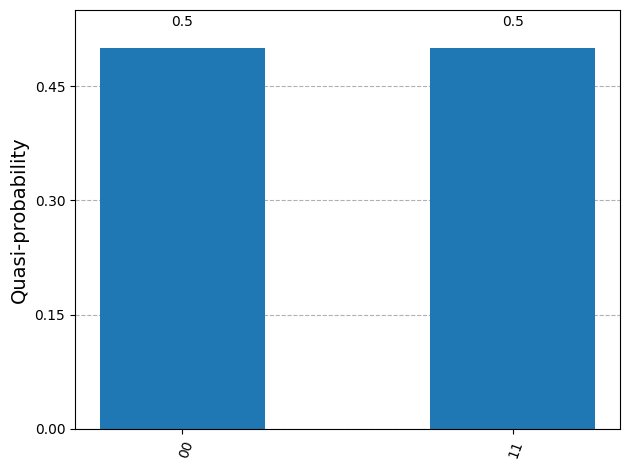

In [10]:

# Your code here
qc=QuantumCircuit(2)
qc.x(0)
qc.h(0)
qc.cx(0,1)
sv=Statevector(qc)
print(sv)
print(sv.data)

# Calculate the determinant
det_value = np.linalg.det(sv.data.reshape((2, 2)))

print(f"Matrix representation of the state:\n{sv}")
print(f"Determinant of the matrix: {det_value}")

if np.isclose(det_value, 0):
    print("Based on the determinant test, this state is a product state (separable).")
else:
    print("Based on the determinant test, this state is an entangled state.")

#plot histogram
plot_histogram(sv.probabilities_dict())

## 3rd bell state

Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
[0.        +0.j 0.70710678+0.j 0.70710678+0.j 0.        +0.j]
Matrix representation of the state:
Statevector([0.        +0.j, 0.70710678+0.j, 0.70710678+0.j,
             0.        +0.j],
            dims=(2, 2))
Determinant of the matrix: (-0.4999999999999999+0j)
Based on the determinant test, this state is an entangled state.


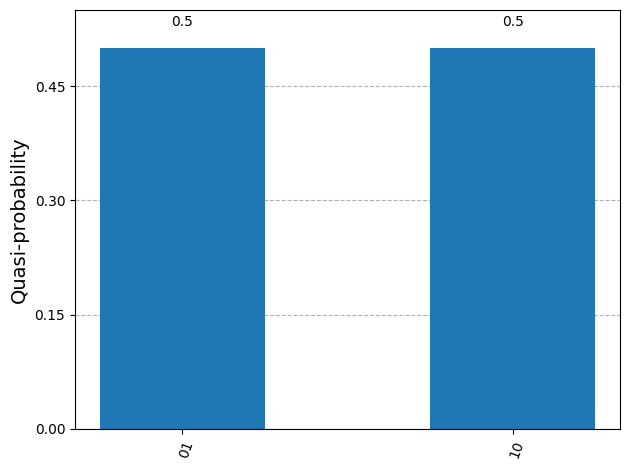

In [11]:
qc=QuantumCircuit(2)
qc.x(1)
qc.h(0)
qc.cx(0,1)
sv=Statevector(qc)
print(sv)
print(sv.data)

# Calculate the determinant
det_value = np.linalg.det(sv.data.reshape((2, 2)))

print(f"Matrix representation of the state:\n{sv}")
print(f"Determinant of the matrix: {det_value}")

if np.isclose(det_value, 0):
    print("Based on the determinant test, this state is a product state (separable).")
else:
    print("Based on the determinant test, this state is an entangled state.")

#plot histogram
plot_histogram(sv.probabilities_dict())

## 4th bell state

Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))
[ 0.        +0.j -0.70710678+0.j  0.70710678+0.j  0.        +0.j]
Matrix representation of the state:
Statevector([ 0.        +0.j, -0.70710678+0.j,  0.70710678+0.j,
              0.        +0.j],
            dims=(2, 2))
Determinant of the matrix: (0.4999999999999999+0j)
Based on the determinant test, this state is an entangled state.


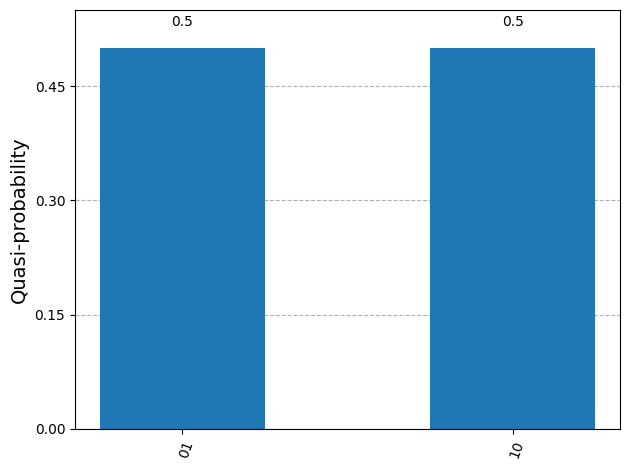

In [13]:
qc=QuantumCircuit(2)
qc.x(0)
qc.x(1)
qc.h(0)
qc.cx(0,1)
sv=Statevector(qc)
print(sv)
print(sv.data)

# Calculate the determinant
det_value = np.linalg.det(sv.data.reshape((2, 2)))

print(f"Matrix representation of the state:\n{sv}")
print(f"Determinant of the matrix: {det_value}")

if np.isclose(det_value, 0):
    print("Based on the determinant test, this state is a product state (separable).")
else:
    print("Based on the determinant test, this state is an entangled state.")

#plot histogram
plot_histogram(sv.probabilities_dict())